# HillClimbing


Created on Thu Nov 27 15:59:22 2025
Changed on Thu Dec 04 12:31:40 2025 -- Add Ackley Problem

@author: gustaaragao

## Objetivo
Aplicar e explorar o **Hill Climbing** em dois problemas:
- **Sphere** (convexo, ótimo global em $x=0$)
- **Ackley** (multimodal, muitos ótimos locais)

O experimento varre hiperparâmetros do HC:
- `p`: probabilidade de perturbar cada variável por iteração
- `r`: amplitude do ruído uniforme (passo)

Critério de parada: `max_evaluations = 50.000` avaliações da função objetivo.

## Sphere Problem

### f(x) = $\Sigma$ x²

- Local optimum = Global optimum -> x* = [0]

In [21]:
from src.problems.Sphere import Sphere
from src.problems.Ackley import Ackley
from src.MOEAs.HillClimbing import HillClimbing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import plot_heatmap_pr, plot_surface_3d, plot_contour

In [ ]:
# Parâmetro do Hill-Climbing
D = 30                                              # Número de variáveis Variáveis de Descisão
max_evaluations = 50_000                            # Número máximo de Avaliações

# Valor de Probabilidade: controla quantas variáveis serão perturbadas a cada iteração
# valores BAIXOS --> MENOS variáveis escolhidas --> maior exploração local (EXPLOITATION)
# valores ALTOS  --> MAIS variáveis escolhidas  --> maior exploração global (EXPLORATION)
p_values = [0.125, 0.25, 0.5, 1.0]

# Range: controla a magnitude do ruído da perturbação
# valores BAIXOS --> passos PEQUENOS --> conversão lenta, fine-tuning
# valores ALTOS  --> passos GRANDES  --> conversão rápida, risco de overshooting
r_values = [0.5, 1.0, 5.0, 10.0, 20.0, 50.0]

In [ ]:
def simulate_sphere(p, r):
    # Cria o problema
    problem = Sphere(numberOfDecisionVariables=D)
    
    # Cria o algoritmo
    algorithm = HillClimbing(
        problem=problem,
        maxEvaluations=max_evaluations,
        probability=p,
        range_noise=r
    )
    
    # Executa o algoritmo
    best = algorithm.execute()
    
    result = {
        'p': p,
        'r': r,
        'best_fitness': best.objectives[0],
        'evaluations': algorithm.evaluations
    }
    
    return result


In [ ]:
rows_sphere = []

# Simula o Hill-Climbing no Sphere Problem
for p in p_values:
    for r in r_values:
        rows_sphere.append(simulate_sphere(p, r))

df_sphere = pd.DataFrame(rows_sphere)
df_sphere

,p,r,best_fitness,evaluations
0,0.125,0.5,0.000825,50000
1,0.125,1.0,0.003324,50000
2,0.125,5.0,0.103949,50000
3,0.125,10.0,0.255681,50000
4,0.125,20.0,0.336044,50000
5,0.125,50.0,2.455222,50000
6,0.250,0.5,0.046454,50000
7,0.250,1.0,0.172597,50000
8,0.250,5.0,4.218830,50000
9,0.250,10.0,6.277594,50000


## Resultados (Sphere): Heatmap p × r
O heatmap abaixo resume o resultado final (`best_fitness`) do Hill Climbing para cada combinação de parâmetros $(p, r)$.
- **Quanto menor o valor, melhor** (problema de minimização).
- A célula com menor valor indica a **melhor configuração observada**.

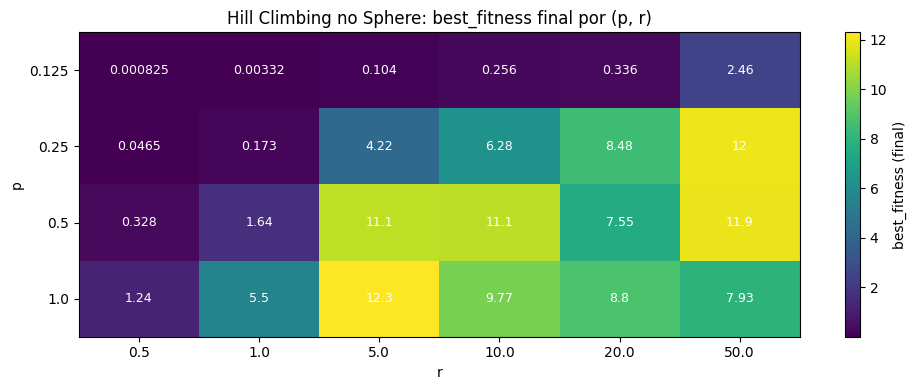

Melhor configuração (Sphere):
p                   0.125000
r                   0.500000
best_fitness        0.000825
evaluations     50000.000000
Name: 0, dtype: float64


In [25]:
# Heatmap do best_fitness por (p, r) usando a função utilitária
plot_heatmap_pr(df_sphere, "Hill Climbing no Sphere: best_fitness final por (p, r)")

# Melhor configuração observada
best_row = df_sphere.loc[df_sphere["best_fitness"].astype(float).idxmin()]
print("Melhor configuração (Sphere):")
print(best_row)

# Gráficos da Função do “Sphere Problem"

In [ ]:
# Gerar gráfico 2D com a solução
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2

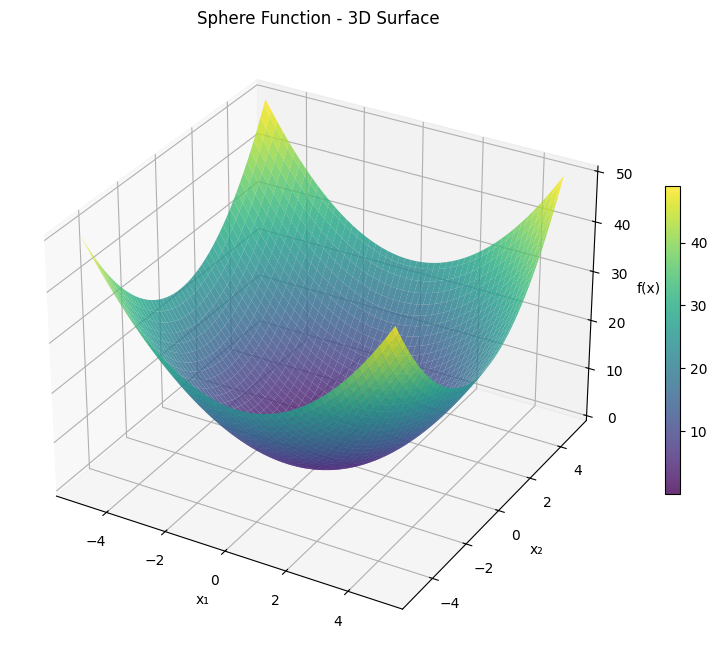

In [38]:
# Gráfico de superfície 3D
plot_surface_3d(X, Y, Z, "Sphere Function - 3D Surface")

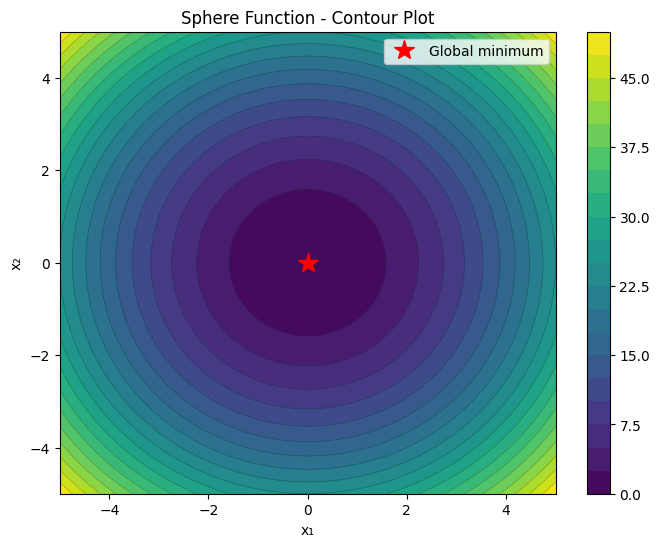

In [39]:
# Gráfico de contorno
plot_contour(X, Y, Z, "Sphere Function - Contour Plot", global_min=(0, 0))

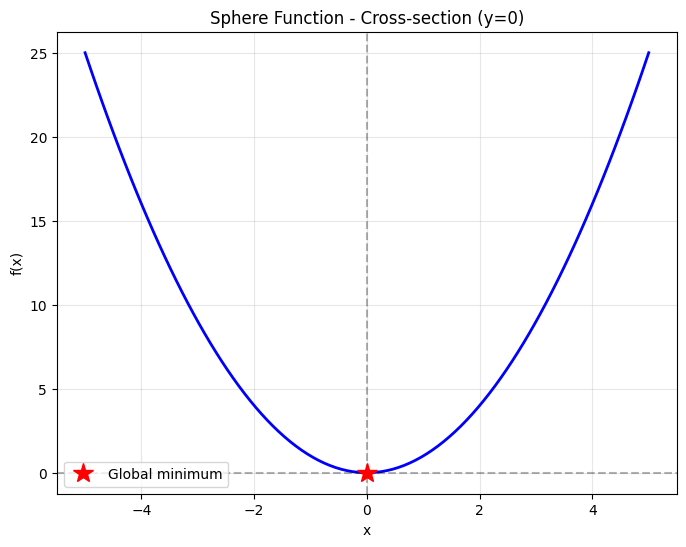

In [40]:
# Gerar gráfico 2D com a solução
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, x**2, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Sphere Function - Cross-section (y=0)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum')
ax.legend()
plt.show()

## Ackley Problem

A função de Ackley (para $D$ variáveis) pode ser escrita como:

$$
f(x) = -a\,\exp\left(-b\,\sqrt{\frac{1}{D}\sum_{i=1}^D x_i^2}\right) - \exp\left(\frac{1}{D}\sum_{i=1}^D \cos(c\,x_i)\right) + a + e
$$

- Global minimum: $x^* = [0,\dots,0]$
- Local minima: a função tem muitos mínimos locais

In [41]:
# Parâmetros
a = 20
b = 0.2
c = 2*np.pi

In [42]:
def simulate_ackley(p, r):
    # Cria o problema
    problem = Ackley(numberOfDecisionVariables=D, a=a, b=b, c=c)
    
    # Cria o algoritmo
    algorithm = HillClimbing(
        problem=problem,
        maxEvaluations=max_evaluations,
        probability=p,
        range_noise=r
    )
    
    # Executa o algoritmo
    best = algorithm.execute()

    result = {
        'p': p,
        'r': r,
        'best_fitness': best.objectives[0],
        'evaluations': algorithm.evaluations
    }
    
    return result

In [43]:
rows_ackley = []

# Simula o Hill-Climbing no Ackley Problem
for p in p_values:
    for r in r_values:
        rows_ackley.append(simulate_ackley(p, r))

df_ackley = pd.DataFrame(rows_ackley)
df_ackley

,p,r,best_fitness,evaluations
0,0.125,0.5,2.222436,50000
1,0.125,1.0,0.050229,50000
2,0.125,5.0,0.328843,50000
3,0.125,10.0,0.590243,50000
4,0.125,20.0,1.598742,50000
5,0.125,50.0,2.830744,50000
6,0.250,0.5,0.211385,50000
7,0.250,1.0,0.525079,50000
8,0.250,5.0,2.991180,50000
9,0.250,10.0,3.405275,50000


## Resultados (Ackley): Heatmap p × r
No Ackley (multimodal), o heatmap ajuda a ver rapidamente quais combinações $(p, r)$ foram mais eficazes em evitar estagnação em mínimos locais.
- **Quanto menor o valor, melhor**.
- Em geral, espera-se maior variabilidade do que no Sphere.

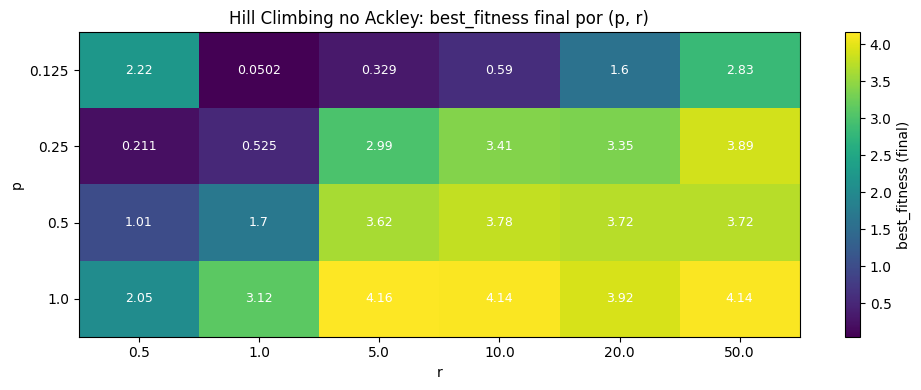

Melhor configuração (Ackley):
p                   0.125000
r                   1.000000
best_fitness        0.050229
evaluations     50000.000000
Name: 1, dtype: float64


In [44]:
plot_heatmap_pr(df_ackley, "Hill Climbing no Ackley: best_fitness final por (p, r)")

best_row_ackley = df_ackley.loc[df_ackley["best_fitness"].astype(float).idxmin()]
print("Melhor configuração (Ackley):")
print(best_row_ackley)

# Gráficos da Função do "Ackley Problem"

In [ ]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

Z = -a * np.exp(-b * np.sqrt(0.5 * (X**2 + Y**2))) - np.exp(
    0.5 * (np.cos(c * X) + np.cos(c * Y))
 ) + a + np.e

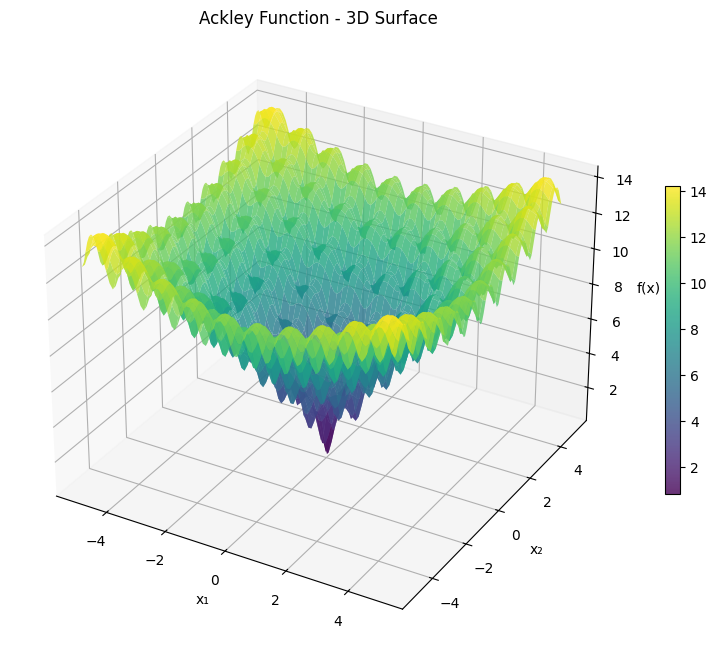

In [35]:
# Gráfico de superfície 3D - Ackley
plot_surface_3d(X, Y, Z, "Ackley Function - 3D Surface")

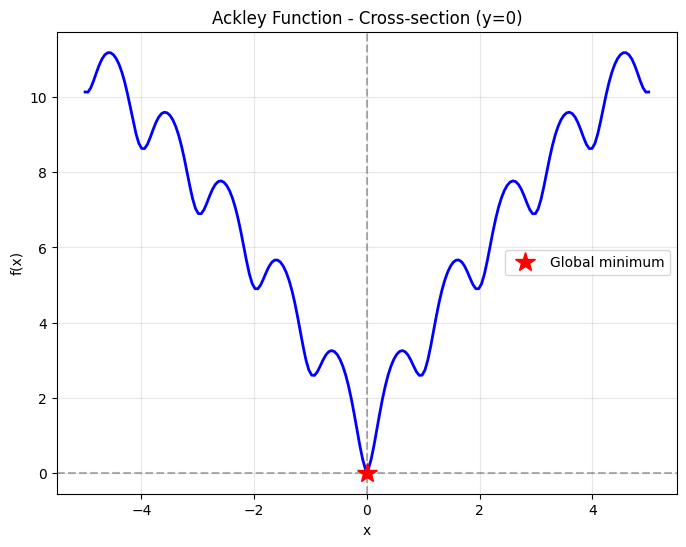

In [ ]:
# Gerar gráfico 2D com a solução
x_1d = np.linspace(-5, 5, 200)
z_1d = (
    -a * np.exp(-b * np.sqrt(0.5 * x_1d**2))
    - np.exp(0.5 * (np.cos(c * x_1d) + 1))
    + a
    + np.e
 )

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_1d, z_1d, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Ackley Function - Cross-section (y=0)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.plot(0, 0, 'r*', markersize=15, label='Global minimum')
ax.legend()
plt.show()